# Sprint 5 - Análisis Exploratorio Descriptivo (Ejercicios)

En estos ejercicios se busca aplicar los conocimientos adquiridos de programación en **R** para profundizar en 3 conceptos de estadística extremadamente útiles para **Análisis Exploratorio de Datos (EDA)** y la aplicación de métodos estadísticos en general:

* Ley de los grandes números.
* Teorema del límite central.

## Ley de los grandes números

La Ley de los grandes números especifica que el estadístico $\bar\theta$ de una muestra de tamaño $n$ extraída de una población cualquiera, convergerá hacía el estadístico poblacional $\theta$ a medida que $n$ aumenta. En términos matemáticos si recurdas algo de límites esta definición sería así:

$$ \lim_{n\rightarrow \infty} \bar\theta = \theta $$

Si consideramos por ejemplo al estadístico **media**, lo que nos dice esta ley es que el promedio de una parte (muestra) de un conjunto de datos (población), será similar al promedio de todo el conjunto siempre que esa parte sea suficientemente grande.

Vamos a probar esto con nuestros conocimientos en estadística y programación en **R**.

### Ejercicio 1

Genera 2,000 valores aleatorios entre 0 y 100 utilizando un bucle y la función `sample`. Guarda estos valores en una variable llamada `poblacion`.

In [1]:
poblacion <- sample(0:100, size = 2000, replace = TRUE)
print(poblacion)

   [1]  90  27  76  82  31  10  86  35  63  47  61  74  38  43  33  25  43  26
  [19]   3  28  28  65  51  98  70  69  61   3  25  20  25  65  26  38  20  94
  [37]   5   3  17  42  81  22  90  82  87   7  68  35  74  28  87  52  13  12
  [55]  87  83  46  11  27  19   0  87  14  65  54  42  42   5  40  89  19  64
  [73]  28  52  66  96  18  49  49  66  75   6  35  74  73  56  18  31  85   9
  [91]   5  58  95  88  27  32 100  31  56  98  19  76  54  79  48  80  66  21
 [109]  55  24  22  24  43  69  70  95  69  23  36  53  60   4  63  70  84  36
 [127]  88  94  94  31  18  50   8  71  39  66   7  80   9  64  25  43  47  63
 [145]   5  50  26  51  95  36   1   9  35  72  60   2  13  47   3  79  75  53
 [163]  55  58  60  22  72  45  93   1  63  80  59  90  18   0  79  97  82   1
 [181]  27  48  36  59  26  88  33  34  16  36  19  55  67  34  91 100   5   6
 [199]  43  23   9  39   1  31  17  58  35  23  72   2  27  70  45  47  69  11
 [217]  54  84  22   8  29  54  25  78  16   6   6  

Calcula el promedio de esta población y guárdala en la variable `prom_poblacion`.

In [2]:
prom_poblacion <- mean(poblacion)
print(prom_poblacion)

[1] 50.3085


Extrae una muestra aleatoria de tamaño 5 de tu población utilizando la función `sample`. Guarda tu resultado en la variable `muestra`.

In [3]:
muestra <- sample(poblacion, size = 5)
print(muestra)

[1]  6 24 27 58  5


Calcula el promedio de esta muestra y guárdala en una variable `prom_muestra`.

In [4]:
prom_muestra <- mean(muestra)
print(prom_muestra)

[1] 24


Es posible que el promedio de la muestra obtenido no sea tan parecido al de la población. No te preocupes, usaremos la lógica de la ley de los grandes números para mejorar esta aproximación.

### Ejercicio 2

Crea un vector atómico `promedios` que contenga cálculos del promedio de muestras de forma equivalente al realizado en el ejercicio anterior. Solamente que ahora considera como tamaño de las muestras valores que inicien en 5 y terminen en 1,500, con saltos de 5 unidades (es decir, 5, 10, 15, 20, 25, ..., 995, 1000, ..., 1495, 1500). 

In [5]:
promedios <- c()
tam_muestra <- 1:300 * 5
for (n in tam_muestra) {
    muestra <- sample(poblacion, size = n)
    promedios <- c(promedios, mean(muestra))
}

Crea un dataframe con **tidyverse** que contenga dos columnas:

* La primera debe especificar los tamaños de muestra que utilizaste en el código anterior.
* La segunda debe especificar los valores guardados en `promedios`.

In [6]:
# Cargar libreria
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [7]:
# Generar dataframe
df_promedios <- tibble(
    n = tam_muestra,
    promedio = promedios
)

glimpse(df_promedios)

Rows: 300
Columns: 2
$ n        <dbl> 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80…
$ promedio <dbl> 33.60000, 56.10000, 49.93333, 44.10000, 51.92000, 56.50000, 4…


Grafica de forma simple la evolución de los promedios obtenidos a medida que se incrementa el tamaño de la muestra. Incluye una linea horizontal en color rojo que muestre el promedio de la población.

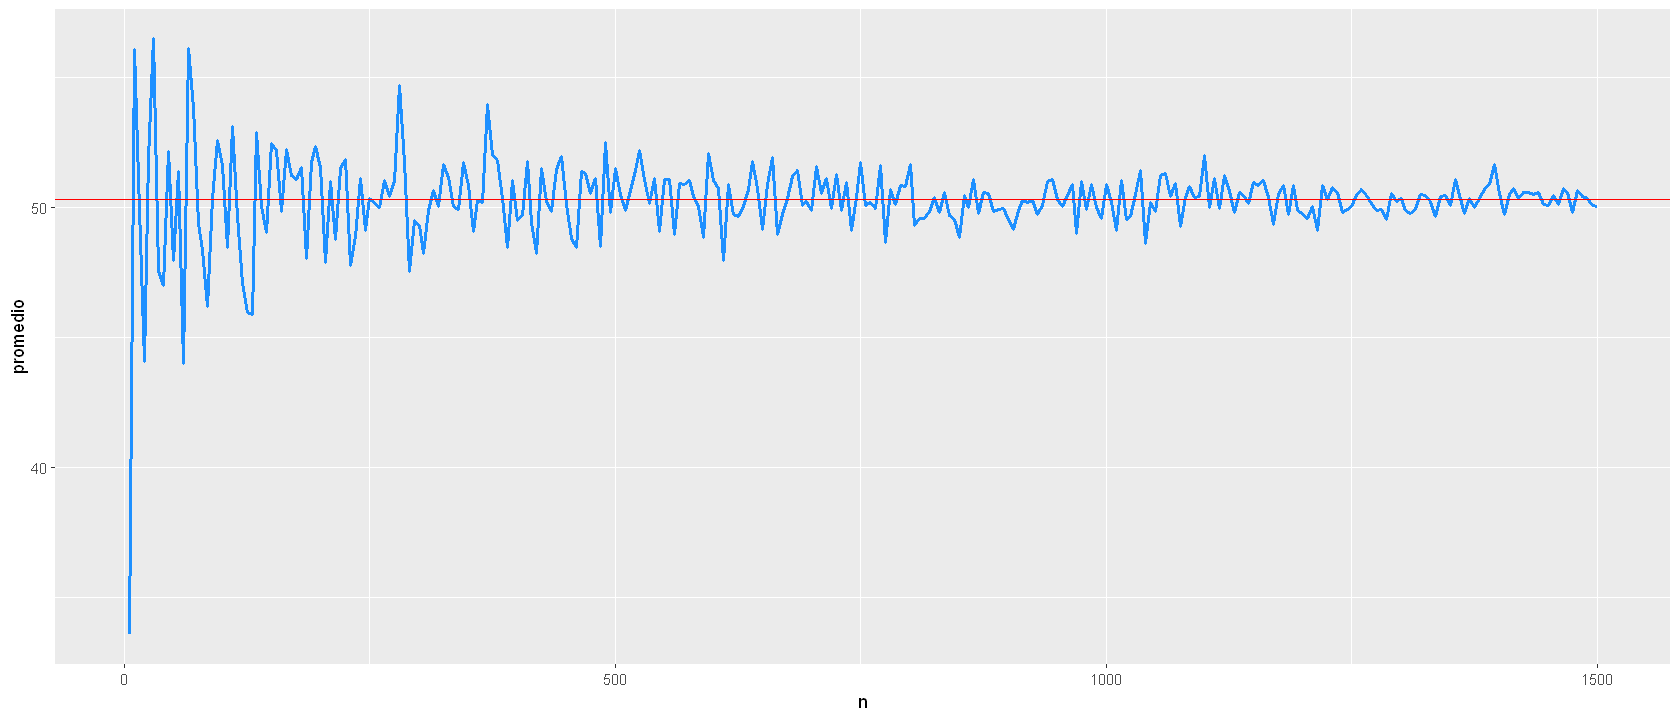

In [8]:
options(repr.plot.width = 14, repr.plot.height = 6)
ggplot(
    data = df_promedios,
    mapping = aes(
        x = n,
        y = promedio
    )
) +
geom_line(
    linewidth = 1,
    color = "dodgerblue"
) + 
geom_hline(
    yintercept = prom_poblacion,
    color = "red"
)

Si todo fue hecho correctamente hasta ahora, deberías evidenciar que el promedio de las muestras converge hacia el promedio de la población a medida que el tamaño de muestra aumenta. Justamente lo que indica la ley de los grandes números.

### Ejercicio 3

Intenta comprobar que esta ley igualmente se cumple para otros estadísticos como la desviación estandar. Puedes utilizar la función `sd`.

In [9]:
# Calcular sd de la poblacion
std_poblacion <- sd(poblacion)
print(std_poblacion)

[1] 28.56148


In [10]:
# Calcular sd para distintos tamaños de muestra
desviaciones = c()
for (n in tam_muestra) {
    muestra <- sample(poblacion, size = n)
    desviaciones <- c(desviaciones, sd(muestra))
}

In [11]:
# Crear dataframe con desviaciones muestrales
df_desviaciones <- tibble(
    n = tam_muestra,
    std = desviaciones
)

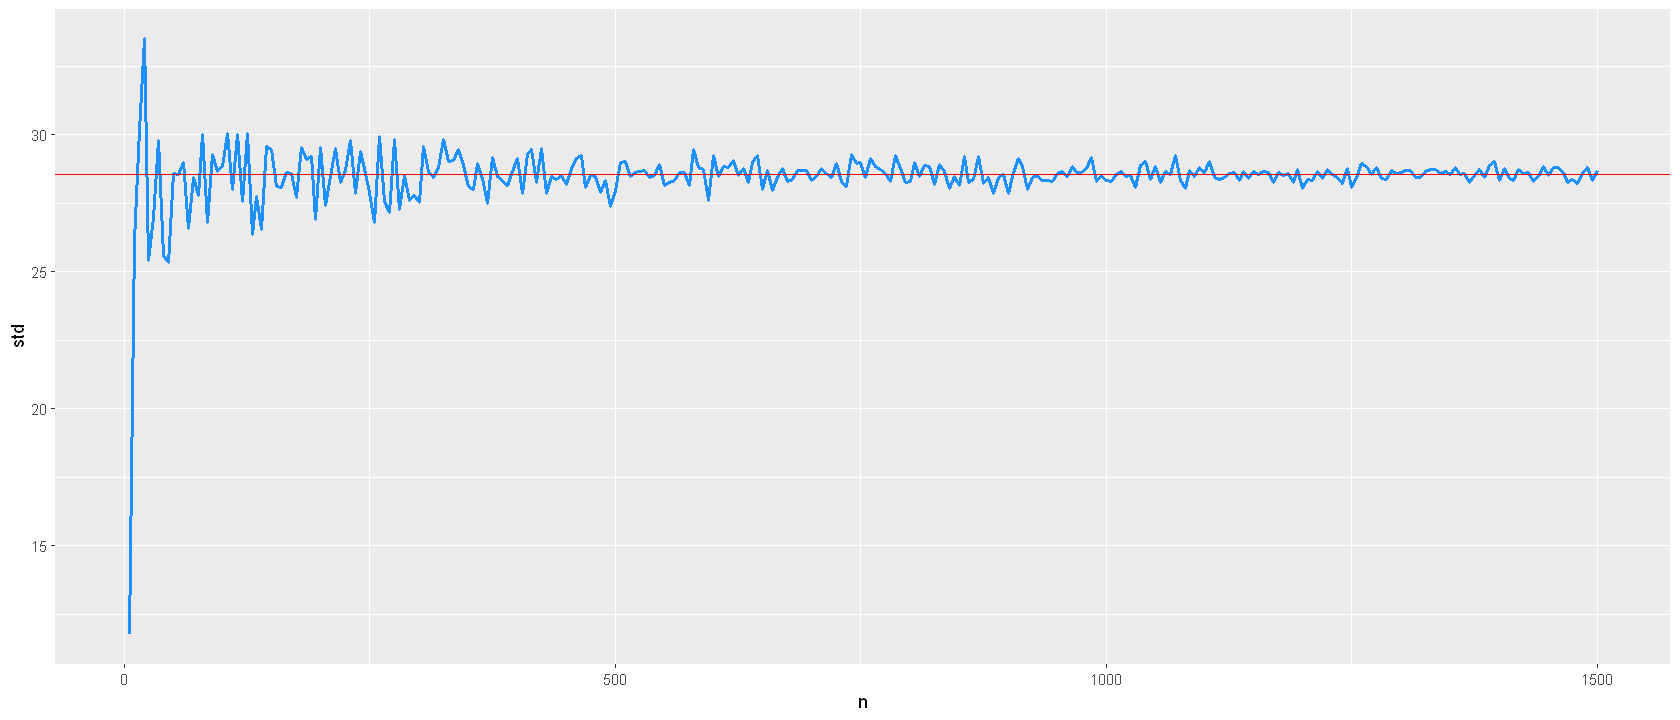

In [12]:
# Graficar evolución de desviaciones
ggplot(
    data = df_desviaciones,
    mapping = aes(
        x = n,
        y = std
    )
) +
geom_line(
    linewidth = 1,
    color = "dodgerblue"
) + 
geom_hline(
    yintercept = std_poblacion,
    color = "red"
)

## Teorema del límite central

El teorema del límite central especifica que la distribución del promedio de una muestra aleatoria extraída de una población, tenderá a ser *Normal* a medida que el tamaño de muestra $n$ se incrementa. Además esta distribución tendrá los siguientes parámetros:

* Centralidad en la media de la población.
* Error estandar $s = \sigma/\sqrt{n}$, donde $\sigma$ corresponde a la desviación estandar poblacional.

En términos más "casuales" aunque no tan precisos, este teorema nos dice que el promedio de cualquier variable sigue una distribución en forma de campana si se cuenta con la suficiente cantidad de observaciones.

El teorema fue planteado ya en 1733 por de Moivre, con las primeras formalizaciones a principios del siglo XIX gracias a las investigaciones de Laplace y Gauss. Su demostración más moderna y formal llegaría un siglo más tarde gracias al trabajo de Lyapunov. Vamos a verificarlo con nuestros conocimientos en estadística y programación con **R**.

### Ejercicio 1

Simula el lanzamiento de un dado común utilizando nuevamente la función `sample`. Por si necesitas saberlo un dado común es aquel que tiene 6 caras y que al lanzarlo cada cara tiene igual probabilidad de salir.

In [13]:
sample(1:6, 1)

[1] 4

Imagina ahora que lanzas el dado 50 veces. Guarda los resultados obtenidos en un vector llamado `lanzamientos`. 

In [14]:
lanzamientos <- sample(1:6, size = 50, replace = TRUE)
print(lanzamientos)

 [1] 5 4 6 3 5 4 5 6 5 2 5 1 4 2 3 4 4 4 1 1 1 2 4 2 4 5 2 6 1 2 5 5 6 4 5 3 5 2
[39] 1 1 3 5 3 4 2 5 5 3 3 3


Calcula el promedio de tus lanzamientos y guarda el resultado en la variable `prom_lanzamientos`.

In [15]:
prom_lanzamientos <- mean(lanzamientos)
print(prom_lanzamientos)

[1] 3.52


Si has hecho todo bien hasta ahora, el promedio obtenido debería ser un valor cercano a $3.5$. ¿Podrías intuir por qué este valor?

### Ejercicio 2

Repite 10 veces este experimento de lanzar 50 dados. Guarda el promedio de cada una de estas iteraciones en una variable llamada `promedios`. 

**NOTA:** Vale señalar que para efectos de asimilar lo solicitado con la definición del Teorema del límite central, nuestro tamaño de muestra $n$ sería 10.  

In [16]:
promedios <- c()
tam_muestra <- 10
for (i in 1:tam_muestra) {
    lanzamientos <- sample(1:6, size = 50, replace = TRUE)
    prom_lanzamientos <- mean(lanzamientos)
    promedios <- c(promedios, prom_lanzamientos)
}

print(promedios)

 [1] 3.78 3.84 3.52 3.68 3.38 3.34 3.38 3.84 3.46 3.70


Grafica estos resultados en un histograma simple que tenga aproximadamente $\sqrt{n}$ columnas. Recuerda que en este caso $n$ sería 10. 

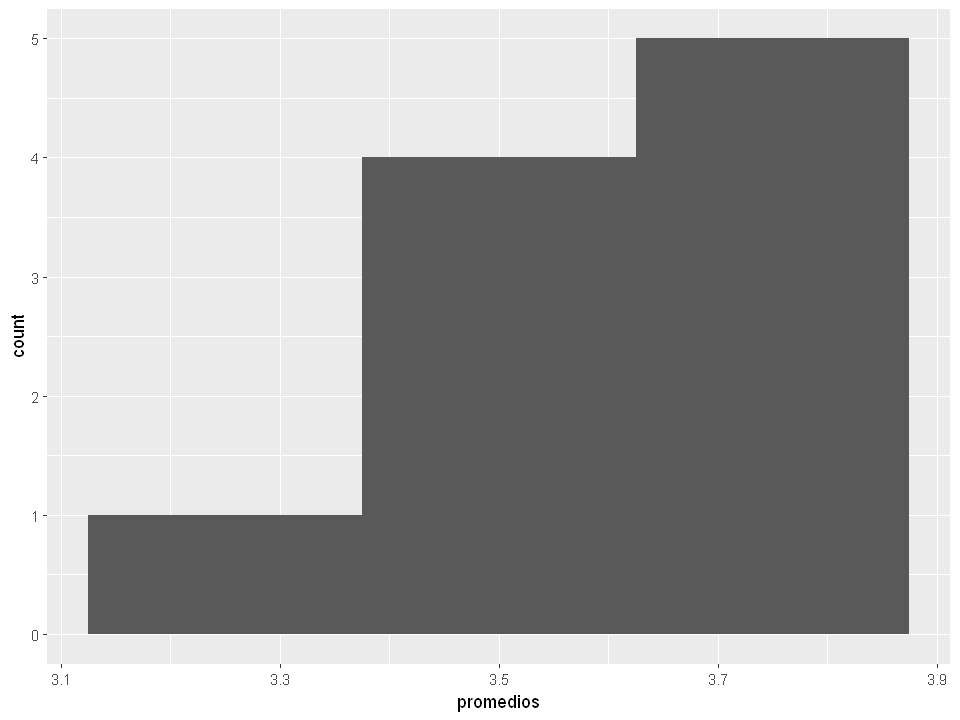

In [17]:
options(repr.plot.width = 8, repr.plot.height = 6)
ggplot() +
geom_histogram(
    mapping = aes(x = promedios),
    bins = as.integer(sqrt(tam_muestra))
)

El gráfico no parece sugerir que este promedio siga una distribución *Normal*. No te preocupes, vamos a llegar a ello con el Teorema del límite central.

### Ejercicio 3

Define la funcion `tlc` que automatice el proceso del ejercicio anterior, tomando como entrada un valor n y devolviendo un histograma. 

In [18]:
tlc <- function (n) {

    # Iterar n veces
    promedios <- c()
    for (i in 1:n) {
        lanzamientos <- sample(1:6, size = 50, replace = TRUE)
        prom_lanzamientos <- mean(lanzamientos)
        promedios <- c(promedios, prom_lanzamientos)
    }

    # Generar histograma
    options(repr.plot.width = 8, repr.plot.height = 6)
    ggplot() +
    geom_histogram(
        mapping = aes(x = promedios),
        bins = as.integer(sqrt(n))
    )

}

Utiliza tu función `tlc` para ver la distribución resultante en un tamaño de muestra $n$ de 100.

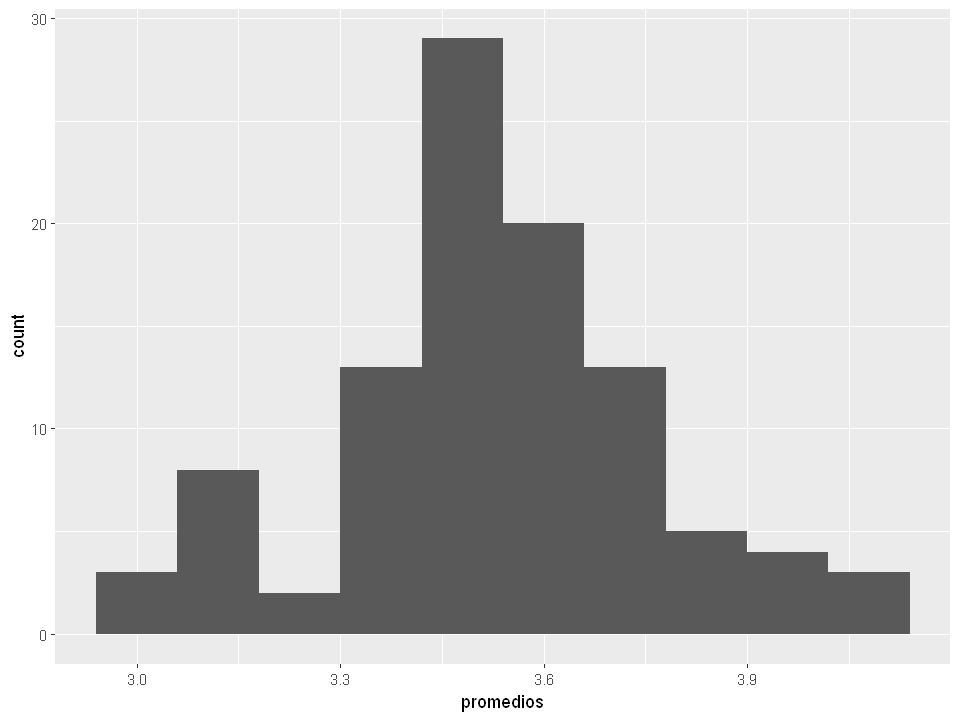

In [19]:
tlc(100)

Repite el ejercicio con tamaños de muestra de 1,000 y 10,000.

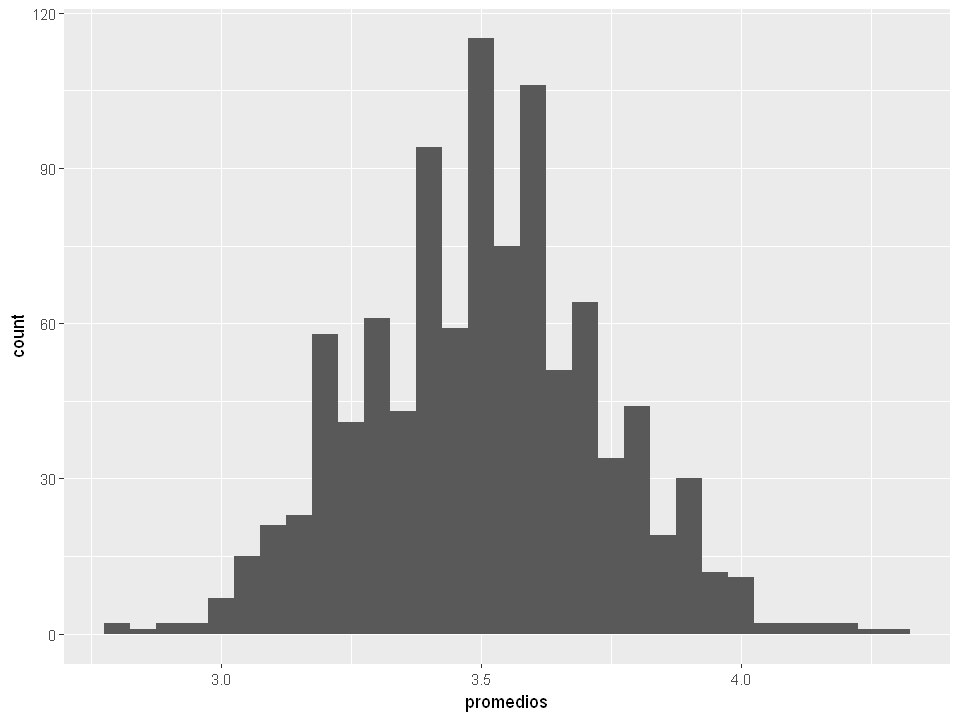

In [20]:
tlc(1000)

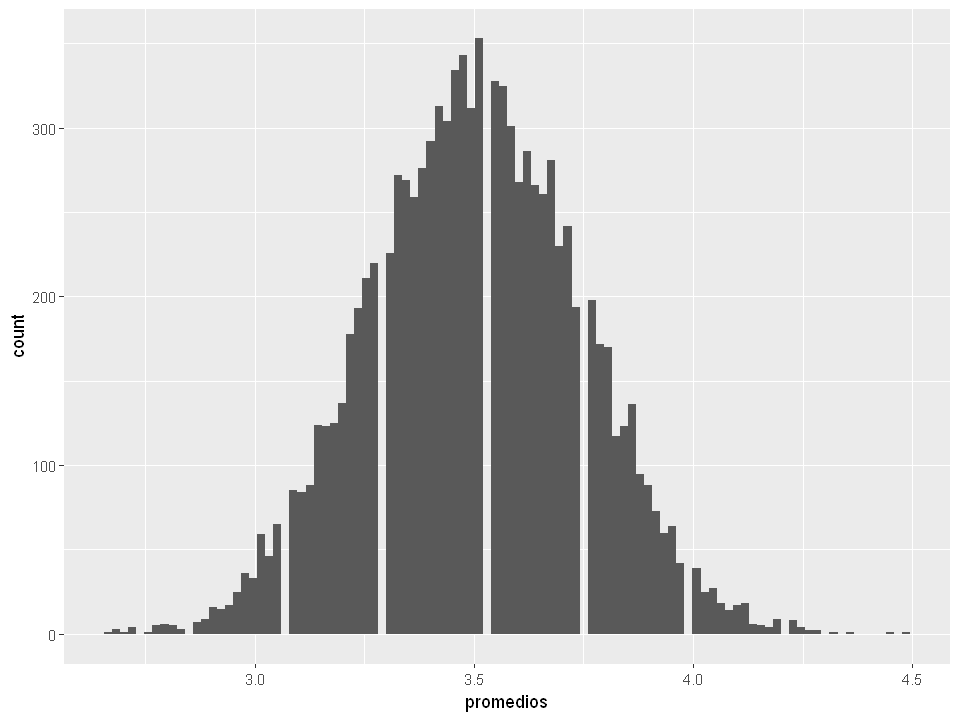

In [21]:
tlc(10000)

Si todo se ha hecho correctamente, notarás que los últimos histogramas tienen una forma muy familiar: la de una distribución *Normal*. Justamente aquella predicha por el Teorema del limite central.

Seguramente te preguntarás cuál es la utilidad de este resultado en tu aprendizaje de analista de datos. Aquí algunas respuestas:

* En inferencia estadística, la existencia y decisión de uso de algunas pruebas de hipótesis (como las asociadas a medias), dependen exclusivamente de que se cumpla esta proposición. Es por este motivo que cuando el tamaño de muestra es pequeño, se sugiere el uso del test U de Mann-Whitney; no así cuando el tamaño de muestra es grande donde se usan las pruebas t que asumen que las medias siguen una distribución simétrica en forma de campana tal y como hace referencia este teorema.
* La confiabilidad y robustez de muchos algoritmos que se utilizan en el modelamiento predictivo y aprendizaje computacional necesitan que las variables a predecir sigan una distribución normal. Por tanto, la agregación a valores promedio puede garantizar el cumplimiento de este requerimiento en específico.
* Pero ante todo, la distribución normal es bastante conocida y documentada, por lo que mantener variables que sigan esta distribución facilita su estudio y comprensión. No sucedería lo mismo si el comportamiento observado tendría propiedades menos "naturales" que exigirían mayor complejidad en nuestros análisis.